In [ ]:
import os
import json
import time
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================
# LSTM — Google Drive Setup
# ============================================

from google.colab import drive
import os
import shutil

# Clean stale mount if present
if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/music-genre-capstone"

FEATURE_ROOT = os.path.join(
    PROJECT_ROOT,
    "data",
    "features"
)

TRAIN_DIR = os.path.join(
    FEATURE_ROOT,
    "training_final"
)

VAL_DIR = os.path.join(
    FEATURE_ROOT,
    "validation_final"
)

TEST_DIR = os.path.join(
    FEATURE_ROOT,
    "test_final"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models",
    "lstm"
)

RESULT_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "lstm"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Drive mounted")
print("Project root:", PROJECT_ROOT)
print("Device:", device)

Mounted at /content/drive
Drive mounted
Project root: /content/drive/MyDrive/music-genre-capstone
Device: cuda


In [ ]:
# ============================================
# LSTM — Locate Feature Shards
# ============================================

train_shards = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

val_shards = sorted([
    os.path.join(VAL_DIR, f)
    for f in os.listdir(VAL_DIR)
    if f.endswith(".npz")
])

test_shards = sorted([
    os.path.join(TEST_DIR, f)
    for f in os.listdir(TEST_DIR)
    if f.endswith(".npz")
])

print("Train shards:", len(train_shards))
print("Validation shards:", len(val_shards))
print("Test shards:", len(test_shards))

# Inspect one training shard
with np.load(train_shards[0]) as data:
    print()
    print("Shard keys:", data.files)
    print("Mel shape:", data["mel_features"].shape)
    print("Mel dtype:", data["mel_features"].dtype)

    if "genre" in data:
        print("Label key: genre")
        print("Label shape:", data["genre"].shape)
    else:
        print("Label key: genres")
        print("Label shape:", data["genres"].shape)

Train shards: 40
Validation shards: 6
Test shards: 6

Shard keys: ['track_id', 'genre', 'ann_features', 'mel_features']
Mel shape: (500, 128, 1292)
Mel dtype: float16
Label key: genre
Label shape: (500,)


In [ ]:
# ============================================
# LSTM — Labels + Efficient Shard Loader
# ============================================

class_names = [
    "Blues",
    "Classical",
    "Country",
    "Easy Listening",
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Jazz",
    "Old-Time / Historic",
    "Pop",
    "Rock",
    "Soul-RnB",
    "Spoken"
]

label_encoder = LabelEncoder()
label_encoder.fit(class_names)

print("Classes:", list(label_encoder.classes_))


class EfficientLSTMShardLoader:

    def __init__(
        self,
        shard_paths,
        label_encoder,
        batch_size=32,
        shuffle=True
    ):
        self.shard_paths = list(shard_paths)
        self.label_encoder = label_encoder
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.total_samples = 0

        for path in self.shard_paths:
            with np.load(path) as data:
                self.total_samples += len(data["mel_features"])

    def __len__(self):
        return (
            self.total_samples + self.batch_size - 1
        ) // self.batch_size

    def __iter__(self):

        shard_order = list(range(len(self.shard_paths)))

        if self.shuffle:
            random.shuffle(shard_order)

        for shard_idx in shard_order:

            path = self.shard_paths[shard_idx]

            with np.load(path) as data:

                mel = data["mel_features"]

                if "genre" in data:
                    labels = data["genre"]
                else:
                    labels = data["genres"]

                indices = np.arange(len(mel))

                if self.shuffle:
                    np.random.shuffle(indices)

                for start in range(
                    0,
                    len(indices),
                    self.batch_size
                ):

                    batch_indices = indices[
                        start:start + self.batch_size
                    ]

                    # float16 -> float32
                    batch_mel = torch.from_numpy(
                        mel[batch_indices].astype(np.float32)
                    )

                    # Normalize [-80, 0] -> [0, 1]
                    batch_mel = (
                        batch_mel + 80.0
                    ) / 80.0

                    batch_mel = torch.clamp(
                        batch_mel,
                        0.0,
                        1.0
                    )

                    # Temporal downsampling:
                    # 1292 -> 323 frames
                    batch_mel = batch_mel[
                        :, :, :1288
                    ]

                    batch_mel = batch_mel.reshape(
                        batch_mel.shape[0],
                        128,
                        322,
                        4
                    ).mean(dim=3)

                    # [batch, 128, 322]
                    # -> [batch, 322, 128]
                    batch_mel = batch_mel.transpose(1, 2)

                    batch_labels = (
                        self.label_encoder.transform(
                            labels[batch_indices]
                        )
                    )

                    batch_labels = torch.tensor(
                        batch_labels,
                        dtype=torch.long
                    )

                    yield batch_mel, batch_labels


train_loader = EfficientLSTMShardLoader(
    train_shards,
    label_encoder,
    batch_size=32,
    shuffle=True
)

val_loader = EfficientLSTMShardLoader(
    val_shards,
    label_encoder,
    batch_size=32,
    shuffle=False
)

test_loader = EfficientLSTMShardLoader(
    test_shards,
    label_encoder,
    batch_size=32,
    shuffle=False
)

print()
print("Train samples:", train_loader.total_samples)
print("Train batches:", len(train_loader))

print("Validation samples:", val_loader.total_samples)
print("Validation batches:", len(val_loader))

print("Test samples:", test_loader.total_samples)
print("Test batches:", len(test_loader))

Classes: [np.str_('Blues'), np.str_('Classical'), np.str_('Country'), np.str_('Easy Listening'), np.str_('Electronic'), np.str_('Experimental'), np.str_('Folk'), np.str_('Hip-Hop'), np.str_('Instrumental'), np.str_('International'), np.str_('Jazz'), np.str_('Old-Time / Historic'), np.str_('Pop'), np.str_('Rock'), np.str_('Soul-RnB'), np.str_('Spoken')]

Train samples: 19909
Train batches: 623
Validation samples: 2504
Validation batches: 79
Test samples: 2572
Test batches: 81


In [ ]:
# ============================================
# LSTM — Batch Shape + Loading Test
# ============================================

start_time = time.time()

batch_x, batch_y = next(iter(train_loader))

print("Input shape:", batch_x.shape)
print("Label shape:", batch_y.shape)
print("Input dtype:", batch_x.dtype)
print("Label dtype:", batch_y.dtype)
print("Input min:", batch_x.min().item())
print("Input max:", batch_x.max().item())
print("Input mean:", batch_x.mean().item())
print("Input std:", batch_x.std().item())
print("Batch loading time:", round(time.time() - start_time, 2), "seconds")

Input shape: torch.Size([32, 322, 128])
Label shape: torch.Size([32])
Input dtype: torch.float32
Label dtype: torch.int64
Input min: 0.0
Input max: 0.9958884716033936
Input mean: 0.4814441204071045
Input std: 0.1913856714963913
Batch loading time: 1.68 seconds


In [ ]:
# ============================================
# LSTM Model
# ============================================

class MusicLSTM(nn.Module):

    def __init__(
        self,
        input_size=128,
        hidden_size=128,
        num_layers=2,
        num_classes=16,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # x: [batch, time, features]
        output, (hidden, cell) = self.lstm(x)

        # Last time step
        x = output[:, -1, :]

        x = self.classifier(x)

        return x


model = MusicLSTM(
    input_size=128,
    hidden_size=128,
    num_layers=2,
    num_classes=16,
    dropout=0.3
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)
print()
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

MusicLSTM(
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
  )
)

Total parameters: 273488
Trainable parameters: 273488


In [ ]:
# ============================================
# LSTM — Forward Pass Test
# ============================================

model.eval()

with torch.no_grad():

    test_x = batch_x.to(device)

    start_time = time.time()

    output = model(test_x)

    inference_time = time.time() - start_time

print("Input shape:", test_x.shape)
print("Output shape:", output.shape)
print("Inference time:", round(inference_time, 4), "seconds")
print("Output dtype:", output.dtype)

Input shape: torch.Size([32, 322, 128])
Output shape: torch.Size([32, 16])
Inference time: 0.6337 seconds
Output dtype: torch.float32


In [ ]:
# ============================================
# LSTM — Training
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_epoch = 0

best_model_state = None

for epoch in range(num_epochs):

    epoch_start = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * batch_x.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == batch_y
        ).sum().item()

        train_total += batch_y.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_x.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == batch_y
            ).sum().item()

            val_total += batch_y.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    # -------------------------
    # Save history
    # -------------------------
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # -------------------------
    # Best checkpoint
    # -------------------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

print()
print("Training complete.")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)

Epoch 1/10 | Train Loss: 2.0438 | Train Acc: 0.3113 | Val Loss: 2.0091 | Val Acc: 0.3279 | Time: 83.2s
Epoch 2/10 | Train Loss: 1.9562 | Train Acc: 0.3277 | Val Loss: 1.9641 | Val Acc: 0.3275 | Time: 81.3s
Epoch 3/10 | Train Loss: 1.9443 | Train Acc: 0.3625 | Val Loss: 2.0677 | Val Acc: 0.3151 | Time: 81.0s
Epoch 4/10 | Train Loss: 1.9103 | Train Acc: 0.3663 | Val Loss: 1.9592 | Val Acc: 0.3502 | Time: 81.2s
Epoch 5/10 | Train Loss: 1.8188 | Train Acc: 0.4188 | Val Loss: 1.8380 | Val Acc: 0.4213 | Time: 81.6s
Epoch 6/10 | Train Loss: 1.7983 | Train Acc: 0.4193 | Val Loss: 1.7522 | Val Acc: 0.4393 | Time: 80.9s
Epoch 7/10 | Train Loss: 1.7429 | Train Acc: 0.4503 | Val Loss: 1.7346 | Val Acc: 0.4421 | Time: 81.5s
Epoch 8/10 | Train Loss: 1.7229 | Train Acc: 0.4537 | Val Loss: 1.7409 | Val Acc: 0.4321 | Time: 79.9s
Epoch 9/10 | Train Loss: 1.6993 | Train Acc: 0.4603 | Val Loss: 1.6636 | Val Acc: 0.4708 | Time: 80.4s
Epoch 10/10 | Train Loss: 1.6775 | Train Acc: 0.4684 | Val Loss: 1.9029 |

In [ ]:
# ============================================
# Save Best LSTM Checkpoint
# ============================================

best_model_path = os.path.join(
    MODEL_DIR,
    "best_lstm_model.pth"
)

torch.save(
    {
        "epoch": best_epoch,
        "val_accuracy": best_val_accuracy,
        "model_state_dict": best_model_state,
        "history": history
    },
    best_model_path
)

print("Saved:", best_model_path)
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)

Saved: /content/drive/MyDrive/music-genre-capstone/models/lstm/best_lstm_model.pth
Best epoch: 9
Best validation accuracy: 0.47084664536741216


In [ ]:
# ============================================
# LSTM — Continue Training to 20 Epochs
# ============================================

checkpoint = torch.load(
    best_model_path,
    map_location="cpu"
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Restore history
history = checkpoint["history"]

best_val_accuracy = checkpoint["val_accuracy"]
best_epoch = checkpoint["epoch"]

model = model.to(device)

# New optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

additional_epochs = 10
start_epoch = best_epoch

for epoch in range(
    start_epoch + 1,
    start_epoch + additional_epochs + 1
):

    epoch_start = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * batch_x.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == batch_y
        ).sum().item()

        train_total += batch_y.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_x.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == batch_y
            ).sum().item()

            val_total += batch_y.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch}/{start_epoch + additional_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch

        torch.save(
            {
                "epoch": best_epoch,
                "val_accuracy": best_val_accuracy,
                "model_state_dict": model.state_dict(),
                "history": history
            },
            best_model_path
        )

        print(
            f"  NEW BEST → "
            f"epoch {best_epoch}, "
            f"val acc {best_val_accuracy:.4f}"
        )

print()
print("Training complete.")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)

Epoch 10/19 | Train Loss: 1.6815 | Train Acc: 0.4665 | Val Loss: 1.6702 | Val Acc: 0.4489 | Time: 82.1s
Epoch 11/19 | Train Loss: 1.6703 | Train Acc: 0.4716 | Val Loss: 1.6910 | Val Acc: 0.4557 | Time: 85.9s
Epoch 12/19 | Train Loss: 1.6633 | Train Acc: 0.4657 | Val Loss: 1.5916 | Val Acc: 0.4836 | Time: 84.0s
  NEW BEST → epoch 12, val acc 0.4836
Epoch 13/19 | Train Loss: 1.6367 | Train Acc: 0.4805 | Val Loss: 1.5880 | Val Acc: 0.4964 | Time: 85.6s
  NEW BEST → epoch 13, val acc 0.4964
Epoch 14/19 | Train Loss: 1.6203 | Train Acc: 0.4809 | Val Loss: 1.5693 | Val Acc: 0.4940 | Time: 83.3s
Epoch 15/19 | Train Loss: 1.6157 | Train Acc: 0.4872 | Val Loss: 1.6056 | Val Acc: 0.4848 | Time: 86.5s
Epoch 16/19 | Train Loss: 1.6001 | Train Acc: 0.4923 | Val Loss: 1.5770 | Val Acc: 0.5120 | Time: 86.4s
  NEW BEST → epoch 16, val acc 0.5120
Epoch 17/19 | Train Loss: 1.5832 | Train Acc: 0.4964 | Val Loss: 1.5224 | Val Acc: 0.5224 | Time: 86.0s
  NEW BEST → epoch 17, val acc 0.5224
Epoch 18/19 | Tr

In [ ]:
# ============================================
# LSTM — Continue Training to 50 Epochs
# ============================================

checkpoint = torch.load(
    best_model_path,
    map_location="cpu"
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

history = checkpoint["history"]

best_val_accuracy = checkpoint["val_accuracy"]
best_epoch = checkpoint["epoch"]

model = model.to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

target_epochs = 50

print("Starting from best epoch:", best_epoch)
print("Current best validation accuracy:", best_val_accuracy)
print("Training until epoch:", target_epochs)
print()

for epoch in range(
    best_epoch + 1,
    target_epochs + 1
):

    epoch_start = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item() * batch_x.size(0)
        )

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == batch_y
        ).sum().item()

        train_total += batch_y.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(
                outputs,
                batch_y
            )

            val_loss += (
                loss.item() * batch_x.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == batch_y
            ).sum().item()

            val_total += batch_y.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    # -------------------------
    # History
    # -------------------------
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch}/{target_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # -------------------------
    # Save NEW best
    # -------------------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch

        torch.save(
            {
                "epoch": best_epoch,
                "val_accuracy": best_val_accuracy,
                "model_state_dict": model.state_dict(),
                "history": history
            },
            best_model_path
        )

        print(
            f"  NEW BEST → "
            f"epoch {best_epoch}, "
            f"val acc {best_val_accuracy:.4f}"
        )

print()
print("Training complete.")
print("Best epoch:", best_epoch)
print(
    "Best validation accuracy:",
    round(best_val_accuracy * 100, 2),
    "%"
)

Starting from best epoch: 17
Current best validation accuracy: 0.5223642172523961
Training until epoch: 50

Epoch 18/50 | Train Loss: 1.5449 | Train Acc: 0.5102 | Val Loss: 1.5981 | Val Acc: 0.4948 | Time: 91.5s
Epoch 19/50 | Train Loss: 1.5408 | Train Acc: 0.5091 | Val Loss: 1.5698 | Val Acc: 0.4748 | Time: 92.1s
Epoch 20/50 | Train Loss: 1.5353 | Train Acc: 0.5109 | Val Loss: 1.5297 | Val Acc: 0.5132 | Time: 91.0s
Epoch 21/50 | Train Loss: 1.5066 | Train Acc: 0.5224 | Val Loss: 1.5202 | Val Acc: 0.5056 | Time: 89.2s
Epoch 22/50 | Train Loss: 1.4866 | Train Acc: 0.5230 | Val Loss: 1.5646 | Val Acc: 0.5012 | Time: 86.3s
Epoch 23/50 | Train Loss: 1.4879 | Train Acc: 0.5267 | Val Loss: 1.4454 | Val Acc: 0.5419 | Time: 88.6s
  NEW BEST → epoch 23, val acc 0.5419
Epoch 24/50 | Train Loss: 1.4616 | Train Acc: 0.5350 | Val Loss: 1.4272 | Val Acc: 0.5459 | Time: 89.3s
  NEW BEST → epoch 24, val acc 0.5459
Epoch 25/50 | Train Loss: 1.4432 | Train Acc: 0.5410 | Val Loss: 1.3739 | Val Acc: 0.573

In [ ]:
# ============================================
# LSTM — Test Best Checkpoint
# ============================================

checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Loaded best epoch:", checkpoint["epoch"])
print("Best validation accuracy:",
      round(checkpoint["val_accuracy"] * 100, 2), "%")

all_predictions = []
all_labels = []

test_loss = 0.0
test_total = 0

start_time = time.time()

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)

        loss = criterion(
            outputs,
            batch_y
        )

        test_loss += (
            loss.item() * batch_x.size(0)
        )

        test_total += batch_y.size(0)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            batch_y.cpu().numpy()
        )

test_time = time.time() - start_time

test_loss /= test_total

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print()
print("Test samples:", test_total)
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy * 100, 2), "%")
print("Evaluation time:", round(test_time, 2), "seconds")

Loaded best epoch: 47
Best validation accuracy: 60.06 %

Test samples: 2572
Test loss: 1.5629
Test accuracy: 55.87 %
Evaluation time: 9.15 seconds


                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.44      0.42      0.43        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         6
         Electronic       0.59      0.81      0.68       632
       Experimental       0.23      0.22      0.22       225
               Folk       0.20      0.12      0.15       152
            Hip-Hop       0.80      0.58      0.67       220
       Instrumental       0.30      0.09      0.14       174
      International       0.11      0.01      0.02       102
               Jazz       0.00      0.00      0.00        39
Old-Time / Historic       0.85      1.00      0.92        51
                Pop       0.00      0.00      0.00       119
               Rock       0.60      0.89      0.72       710
           Soul-RnB       0.00      0.00      0.00        42
             Spoken    

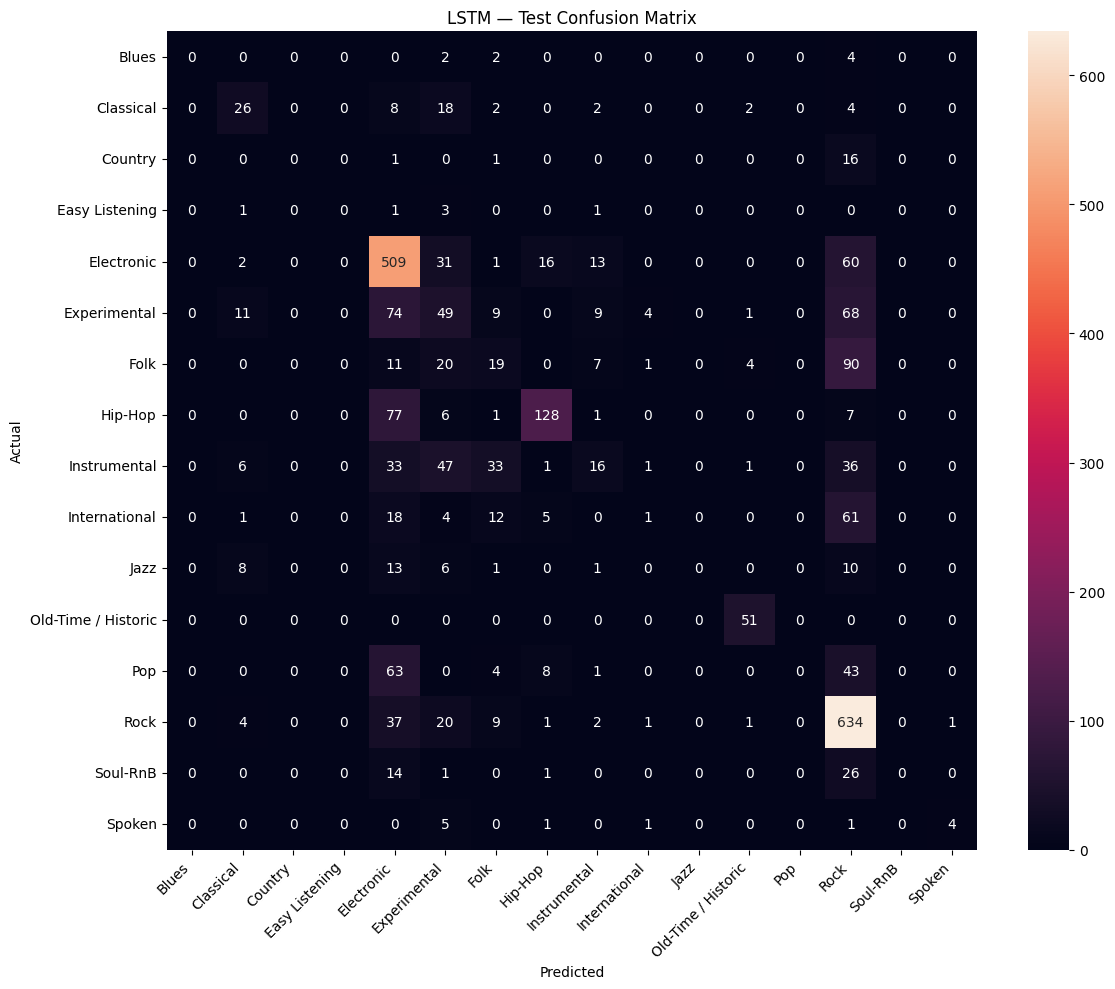

In [ ]:
# ============================================
# LSTM — Classification Report + Confusion Matrix
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=2,
    zero_division=0
)

print(report)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM — Test Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# LSTM — Save Final Test Results
# ============================================

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = \
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

results = {
    "model": "LSTM",
    "architecture": {
        "input_size": 128,
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "classifier": [128, 64, 16]
    },
    "parameters": 273488,
    "best_epoch": int(checkpoint["epoch"]),
    "best_validation_accuracy": float(
        checkpoint["val_accuracy"]
    ),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(precision),
    "macro_recall": float(recall),
    "macro_f1": float(f1),
    "weighted_precision": float(weighted_precision),
    "weighted_recall": float(weighted_recall),
    "weighted_f1": float(weighted_f1),
    "test_samples": int(test_total),
    "evaluation_time_seconds": float(test_time),
    "classification_report": classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
}

results_path = os.path.join(
    RESULT_DIR,
    "lstm_results.json"
)

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print("Results saved:")
print(results_path)

print()
print("LSTM FINAL")
print("Best epoch:", checkpoint["epoch"])
print("Validation accuracy:",
      round(checkpoint["val_accuracy"] * 100, 2), "%")
print("Test accuracy:",
      round(test_accuracy * 100, 2), "%")
print("Macro F1:",
      round(f1, 4))
print("Weighted F1:",
      round(weighted_f1, 4))

Results saved:
/content/drive/MyDrive/music-genre-capstone/results/lstm/lstm_results.json

LSTM FINAL
Best epoch: 47
Validation accuracy: 60.06 %
Test accuracy: 55.87 %
Macro F1: 0.2768
Weighted F1: 0.4928


In [1]:
import glob

ROOT = "/content/drive/MyDrive/music-genre-capstone"

matches = sorted(set(
    glob.glob(f"{ROOT}/**/*lstm*.pth", recursive=True) +
    glob.glob(f"{ROOT}/**/*lstm*.json", recursive=True)
))

for path in matches:
    print(path)

print("\nTotal:", len(matches))


Total: 0


In [2]:
import os

ROOT = "/content/drive/MyDrive/music-genre-capstone"

for root, dirs, files in os.walk(ROOT):
    for file in files:
        if "lstm" in file.lower():
            print(os.path.join(root, file))

In [3]:
import os

ROOT = "/content/drive/MyDrive/music-genre-capstone"

extensions = {".pth", ".pt", ".ckpt", ".json", ".csv", ".txt", ".yaml", ".yml"}

for root, dirs, files in os.walk(ROOT):
    for file in files:
        if os.path.splitext(file)[1].lower() in extensions:
            print(os.path.join(root, file))

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

ROOT = "/content/drive/MyDrive/music-genre-capstone"

print("Project exists:", os.path.exists(ROOT))
print("Contents:")
print(os.listdir(ROOT))

Project exists: True
Contents:
['data', 'features', 'checkpoints', 'test_1gb.bin', 'models', 'results']


In [6]:
import glob

matches = sorted(set(
    glob.glob(f"{ROOT}/**/*lstm*.pth", recursive=True) +
    glob.glob(f"{ROOT}/**/*lstm*.pt", recursive=True) +
    glob.glob(f"{ROOT}/**/*lstm*.json", recursive=True)
))

for path in matches:
    print(path)

print("\nTotal:", len(matches))

/content/drive/MyDrive/music-genre-capstone/models/lstm/best_lstm_model.pth
/content/drive/MyDrive/music-genre-capstone/results/lstm/lstm_results.json

Total: 2


In [7]:
import json

RESULTS = "/content/drive/MyDrive/music-genre-capstone/results/lstm/lstm_results.json"

with open(RESULTS, "r") as f:
    results = json.load(f)

print(json.dumps(results, indent=2))

{
  "model": "LSTM",
  "architecture": {
    "input_size": 128,
    "hidden_size": 128,
    "num_layers": 2,
    "dropout": 0.3,
    "classifier": [
      128,
      64,
      16
    ]
  },
  "parameters": 273488,
  "best_epoch": 47,
  "best_validation_accuracy": 0.6006389776357828,
  "test_loss": 1.5629386367916505,
  "test_accuracy": 0.5587091757387247,
  "macro_precision": 0.30766433401841464,
  "macro_recall": 0.27983622309440126,
  "macro_f1": 0.2767523547748221,
  "weighted_precision": 0.46692078885258753,
  "weighted_recall": 0.5587091757387247,
  "weighted_f1": 0.49277644903626744,
  "test_samples": 2572,
  "evaluation_time_seconds": 9.14570164680481,
  "classification_report": {
    "Blues": {
      "precision": 0.0,
      "recall": 0.0,
      "f1-score": 0.0,
      "support": 8.0
    },
    "Classical": {
      "precision": 0.4406779661016949,
      "recall": 0.41935483870967744,
      "f1-score": 0.4297520661157025,
      "support": 62.0
    },
    "Country": {
      "precis

In [8]:
import torch

CHECKPOINT = "/content/drive/MyDrive/music-genre-capstone/models/lstm/best_lstm_model.pth"

checkpoint = torch.load(CHECKPOINT, map_location="cpu")

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nKeys:")
    for key in checkpoint.keys():
        print(" ", key)

    print("\nMetadata:")
    for key, value in checkpoint.items():
        if not isinstance(value, dict):
            print(key, ":", value)

Checkpoint type: <class 'dict'>

Keys:
  epoch
  val_accuracy
  model_state_dict
  history

Metadata:
epoch : 47
val_accuracy : 0.6006389776357828
